In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp

n=40
R=0.6

# Initialize the training dataset

def generate_data(R, num_points_per_class=20):
    """Generates the deterministic 2D dataset."""
    angles = np.linspace(0, 2 * np.pi, num_points_per_class, endpoint=False)

    positive_points = np.zeros((num_points_per_class, 2))
    positive_points[:, 0] = 1 + R * np.cos(angles)
    positive_points[:, 1] = R * np.sin(angles)

    negative_points = np.zeros((num_points_per_class, 2))
    negative_points[:, 0] = -1 + R * np.cos(angles)
    negative_points[:, 1] = R * np.sin(angles)

    X = np.vstack([positive_points, negative_points])
    y = np.array([1] * num_points_per_class + [-1] * num_points_per_class)

    return X, y

X , y = generate_data(R)


Matplotlib is building the font cache; this may take a moment.


Perceptron converged after 1 updates.


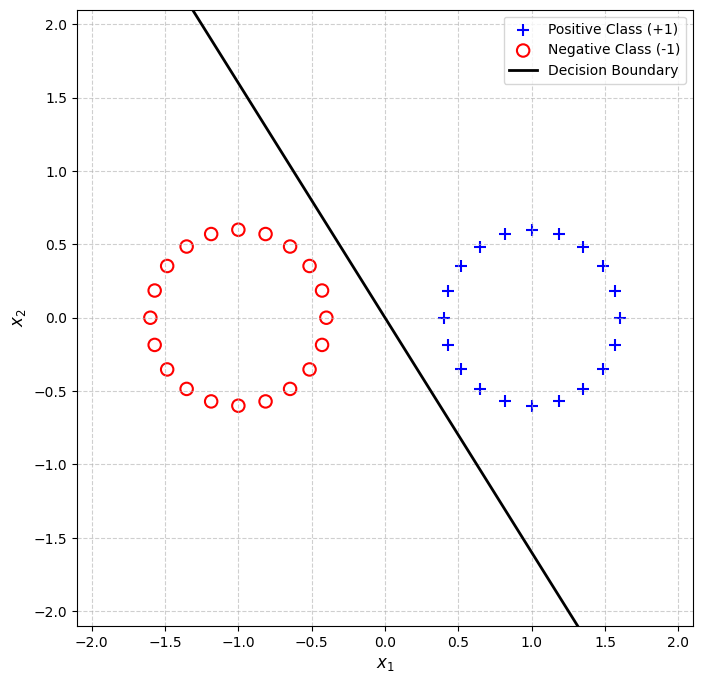

In [3]:
# (a) Perceptron
# Plot the classifier it converges to on a catter plot of the data

def calculate_losses(X, y, w):
    """Helper to calculate hinge, 0/1, and logistic loss."""
    margins = y * (X @ w)
    hinge = np.maximum(0.0, 1 - margins).mean()
    error = np.mean(margins <= 0)
    logistic = np.logaddexp(0, -margins).mean()
    return {'hinge_loss': hinge, 'train_error': error, 'logistic_loss': logistic}


def perceptron(X, y, max_iter=1000):
    w = np.array([0.0, 1.0])
    history = [calculate_losses(X, y, w)]
    for iteration in range(max_iter):
        misclassified_found = False
        for i in range(len(y)):
            if y[i]*(w @ X[i]) <= 0:
                w = w + y[i] * X[i]
                history.append(calculate_losses(X, y, w))
                misclassified_found = True
                break
        if not misclassified_found:
            print(f"Perceptron converged after {len(history)-1} updates.")
            break
    if iteration == max_iter - 1: print(f"Perceptron reached max iterations ({max_iter}).")
    return w, history


def plot_classifier(X, y, w=None, title=""):
    """Plots the 2D dataset and the decision boundary with nice axes."""
    plt.figure(figsize=(8, 8))
    plt.scatter(X[y==1, 0], X[y==1, 1], color='blue', marker='+', s=80, label='Positive Class (+1)')
    plt.scatter(X[y==-1, 0], X[y==-1, 1], color='red', marker='o', s=80, label='Negative Class (-1)', facecolors='none', linewidths=1.5)

    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    padding = 0.5
    plt.xlim(x_min - padding, x_max + padding)
    plt.ylim(x_min - padding, x_max + padding)
    plt.gca().set_aspect('equal', adjustable='box')

    if w is not None and np.linalg.norm(w) > 1e-8:
        x1_lim = np.array(plt.xlim())
        if np.abs(w[1]) > 1e-6:
            x2_lim = -(w[0] / w[1]) * x1_lim
            plt.plot(x1_lim, x2_lim, 'k-', linewidth=2, label='Decision Boundary')
        else:
            plt.axvline(0, color='k', linestyle='-', linewidth=2, label='Decision Boundary')

    plt.xlabel('$x_1$', fontsize=12)
    plt.ylabel('$x_2$', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

w, history = perceptron(X, y)
plot_classifier(X, y, w, title="")

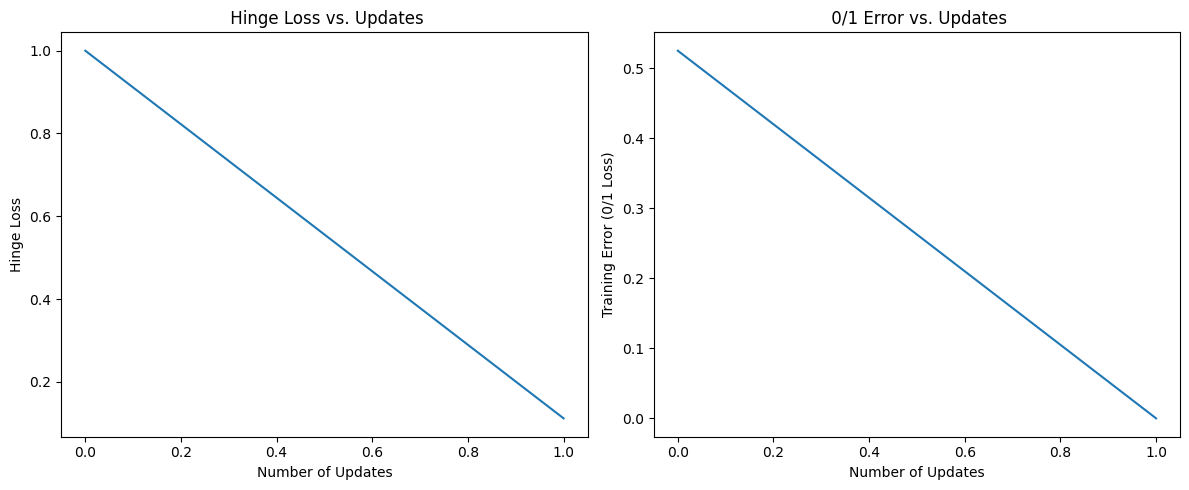

In [4]:
#Track and plot the hinge loss and the training error (0/1 loss) as a function of the number of updates


def plot_loss_curves(history, title_prefix=""):
    """Plots the hinge loss and 0/1 error over updates."""
    hinge_loss = [h['hinge_loss'] for h in history]
    train_error = [h['train_error'] for h in history]

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(hinge_loss)
    plt.title(f'{title_prefix} Hinge Loss vs. Updates')
    plt.xlabel('Number of Updates')
    plt.ylabel('Hinge Loss')

    plt.subplot(1, 2, 2)
    plt.plot(train_error)
    plt.title(f'{title_prefix} 0/1 Error vs. Updates')
    plt.xlabel('Number of Updates')
    plt.ylabel('Training Error (0/1 Loss)')

    plt.tight_layout()
    plt.show()

plot_loss_curves(history, title_prefix="")
    

Perceptron converged after 5 updates.


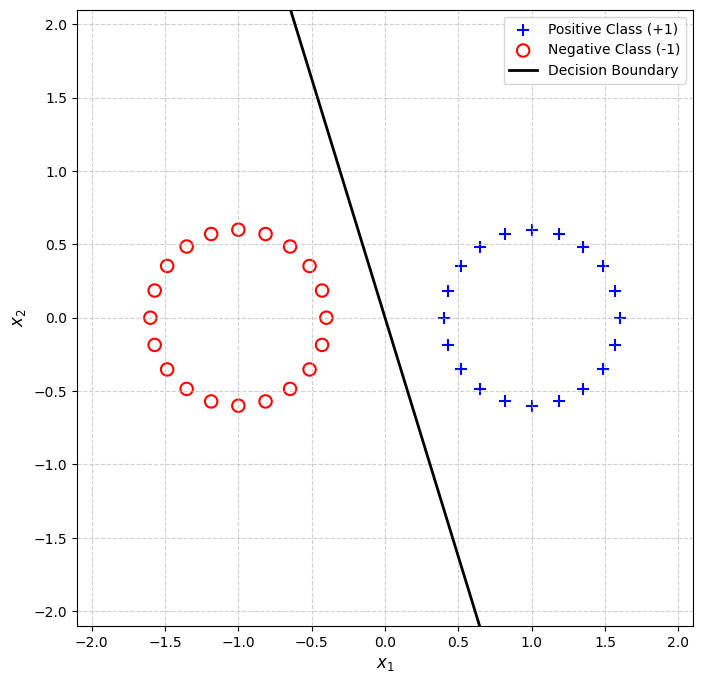

In [5]:
# (b) Analogue of Perceptron for Hinge-Loss

def sgd_hinge(X, y, max_iter=1000):
    w = np.array([0.0, 1.0])
    history = [calculate_losses(X, y, w)]
    eta = 1.0
    for iteration in range(max_iter):
        misclassified_found = False
        for i in range(len(y)):
            if y[i]*(w @ X[i]) <= 1:
                w = w + eta * y[i] * X[i]
                history.append(calculate_losses(X, y, w))
                misclassified_found = True
                break
        if not misclassified_found:
            print(f"Perceptron converged after {len(history)-1} updates.")
            break
    if iteration == max_iter - 1: print(f"Perceptron reached max iterations ({max_iter}).")
    return w, history



w2, history2 = sgd_hinge(X, y)
plot_classifier(X, y, w2, title="")

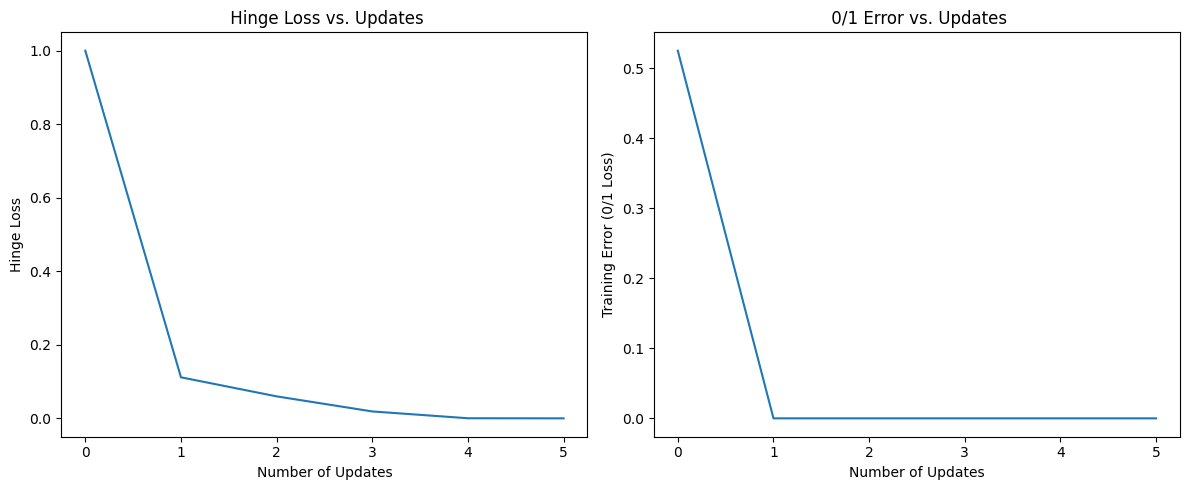

In [6]:
# Track and plot the hinge loss and the training error as a function of updates


plot_loss_curves(history2, title_prefix="")

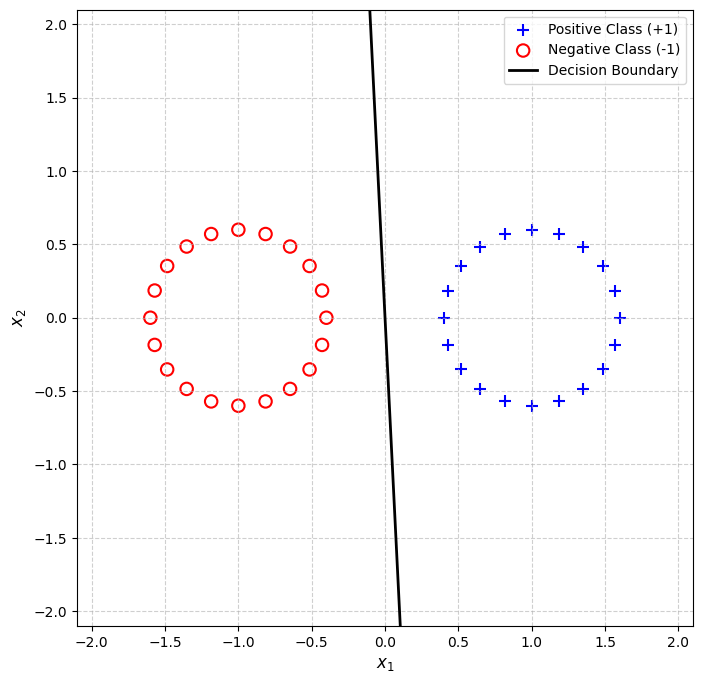

In [7]:
# (c) Logistic Regression


def logistic_regression_gd(X, y, eta=0.5, iterations=500):
    w = np.array([0.0, 1.0])
    history = [calculate_losses(X, y, w)]
    for iteration in range(iterations):
        margins = y * (X @ w)            
        s = sigmoid(-margins)            
        grad = (X.T @ (s * y)) / n       
        w = w + eta * grad               
        history.append(calculate_losses(X, y, w)) 
    return w, history


def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

w3, history3 = logistic_regression_gd(X, y, eta=0.5, iterations=500)
plot_classifier(X, y, w3, title="")

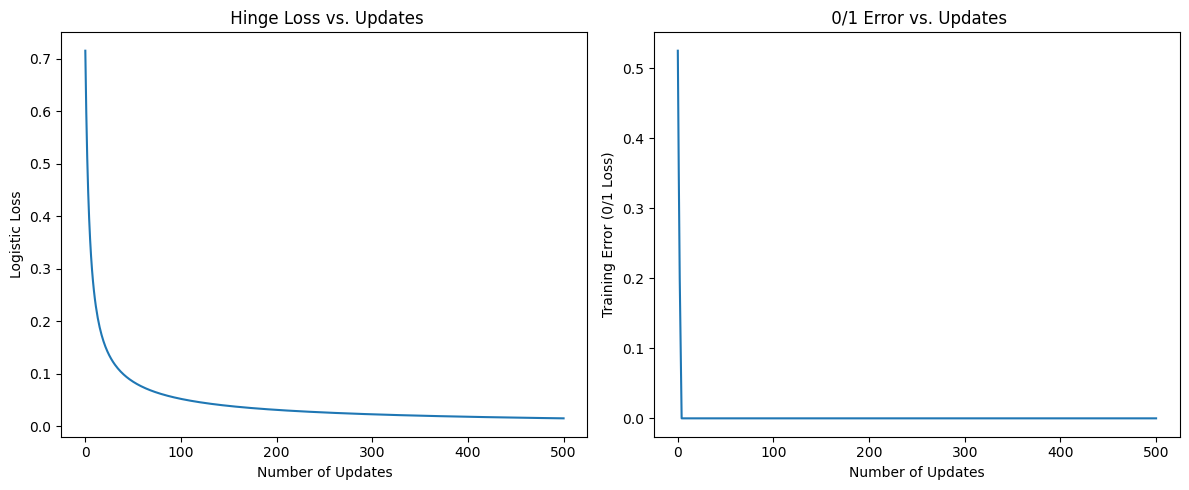

Final logistic loss: 0.014799


In [8]:
# Track and plot the logistics loss and the training error as a function of iterations

def plot_logistic_loss_curves(history, title_prefix=""):
    """Plots the logistic loss and 0/1 error over updates."""
    logistic_loss = [h['logistic_loss'] for h in history]
    train_error = [h['train_error'] for h in history]

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(logistic_loss)
    plt.title(f'{title_prefix} Logistic Loss vs. Updates')
    plt.xlabel('Number of Updates')
    plt.ylabel('Logistic Loss')

    plt.subplot(1, 2, 2)
    plt.plot(train_error)
    plt.title(f'{title_prefix} 0/1 Error vs. Updates')
    plt.xlabel('Number of Updates')
    plt.ylabel('Training Error (0/1 Loss)')

    plt.tight_layout()
    plt.show()

plot_logistic_loss_curves(history3, title_prefix="")
final_logloss = history3[-1]['logistic_loss']
print(f"Final logistic loss: {final_logloss:.6f}")

In [9]:
# (c) 3

norm_p = np.linalg.norm(w)
norm_h = np.linalg.norm(w2)          
norm_l = np.linalg.norm(w3)          
print(norm_p, norm_h, norm_l)

1.886796226411321 3.408714629280829 6.573427027318878


In [10]:
# (e) The Max-Margin Classifier
# 2

def solve_cvxpy(X, y):
    n, d = X.shape
    w_var = cp.Variable(d)
    objective = cp.Minimize(cp.sum_squares(w_var))   # ||w||_2^2
    constraints = [ y[i] * (X[i] @ w_var) >= 1 for i in range(n) ]
    prob = cp.Problem(objective, constraints)
    prob.solve()
    return w_var.value

w_min = solve_cvxpy(X, y)
print("Minimizer is:", w_min)

Minimizer is: [2.50000000e+00 2.29621265e-16]


In [11]:
# 3

def cosine(u, v):
    return float(u @ v) / (np.linalg.norm(u) * np.linalg.norm(v))

cos_p = cosine(w_min, w)
cos_h = cosine(w_min, w2)
cos_l = cosine(w_min, w3)

print(f"cos(perceptron)   = {cos_p:.4f}")
print(f"cos(hinge-SGD)    = {cos_h:.4f}")
print(f"cos(logistic-GD)  = {cos_l:.4f}")

cos(perceptron)   = 0.8480
cos(hinge-SGD)    = 0.9560
cos(logistic-GD)  = 0.9988


In [13]:
# (f) Last one

def generate_data(R, num_points_per_class=20):
    """Generates the deterministic 2D dataset."""
    angles = np.linspace(0, 2 * np.pi, num_points_per_class, endpoint=False)

    positive_points = np.zeros((num_points_per_class, 2))
    positive_points[:, 0] = 1 + R * np.cos(angles)
    positive_points[:, 1] = R * np.sin(angles)

    negative_points = np.zeros((num_points_per_class, 2))
    negative_points[:, 0] = -1 + R * np.cos(angles)
    negative_points[:, 1] = R * np.sin(angles)

    X = np.vstack([positive_points, negative_points])
    y = np.array([1] * num_points_per_class + [-1] * num_points_per_class)

    return X, y

R2 = 1.2
X2 , y2 = generate_data(R2)
w4, history4 = perceptron(X2, y2)          # Perceptron

Perceptron reached max iterations (1000).


Perceptron reached max iterations (1000).


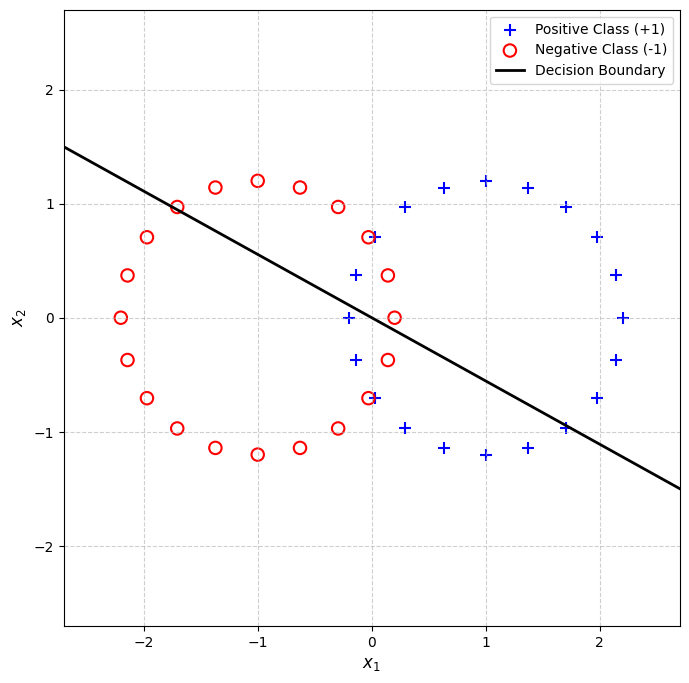

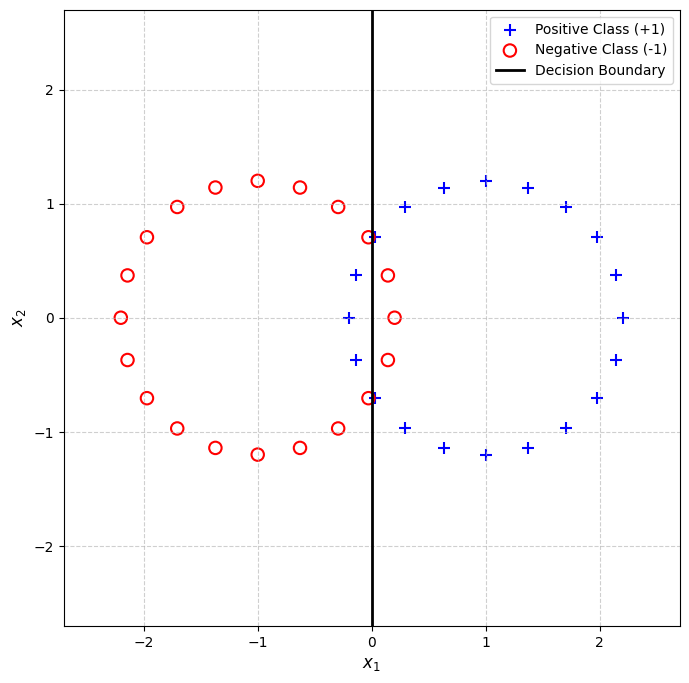

Final training error for Hinge_SGD: 0.400000
Final training error for logistic regression: 0.150000


In [17]:
# Run Hinge_SGD and Logistic Regression algorithm

w5, history5 = sgd_hinge(X2, y2)
plot_classifier(X2, y2, w5, title="")

w6, history6 = logistic_regression_gd(X2, y2, eta=0.5, iterations=500)
plot_classifier(X2, y2, w6, title="")

train_error1 = history5[-1]['train_error']
print(f"Final training error for Hinge_SGD: {train_error1:.6f}")

train_error2 = history6[-1]['train_error']
print(f"Final training error for logistic regression: {train_error2:.6f}")